In [1]:
import os
import sys
import numpy as np
import awkward
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool, global_max_pool
sys.path.append('../')
from helper import *

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Config

DATA_PATH   = "dataset"
BATCH_SIZE  = 32
K_NEIGHBORS = 16
HIDDEN_DIM  = 16
N_LAYERS    = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = {
    "epochs":       100,
    "lr":           1e-3,
    "optimizer":    "adam",
    "loss_fn":      nn.MSELoss(),
    "cosine":       {"T_max": 100},
    "early_stop":   {"patience": 15},
    "save_path":    "logs/gnn_train_log.csv",
    "model_name":   "gnn_icecube",
}

In [3]:
# Load raw datasets

train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset   = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset  = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [4]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

In [5]:
# Normalize data

t_mean = awkward.mean(train_dataset["data"][:, 0, :])
t_std  = awkward.std(train_dataset["data"][:, 0, :])

x_mean = awkward.mean(train_dataset["data"][:, 1, :])
x_std  = awkward.std(train_dataset["data"][:, 1, :])

y_mean = awkward.mean(train_dataset["data"][:, 2, :])
y_std  = awkward.std(train_dataset["data"][:, 2, :])

xpos_mean = awkward.mean(train_dataset["xpos"])
xpos_std  = awkward.std( train_dataset["xpos"])

ypos_mean = awkward.mean(train_dataset["ypos"])
ypos_std  = awkward.std( train_dataset["ypos"])

In [6]:
def normalise_dataset(ds):
    norm_t = (ds["data"][:, 0:1, :] - t_mean) / t_std
    norm_x = (ds["data"][:, 1:2, :] - x_mean) / x_std
    norm_y = (ds["data"][:, 2:3, :] - y_mean) / y_std
    ds["data"] = awkward.concatenate([norm_t, norm_x, norm_y], axis=1)
    ds["xpos"] = (ds["xpos"] - xpos_mean) / xpos_std
    ds["ypos"] = (ds["ypos"] - ypos_mean) / ypos_std
    return ds

In [7]:
train_dataset = normalise_dataset(train_dataset)
val_dataset   = normalise_dataset(val_dataset)
test_dataset  = normalise_dataset(test_dataset)

In [8]:
def collate_fn_gnn(batch):
    data_list, labels = [], []
    for b in batch:
        # transpose from (3, n_hits) to (n_hits, 3) — PyG wants nodes as rows
        tensordata = torch.from_numpy(b["data"].to_numpy()).T.to(dtype=torch.float32)
        data_list.append(Data(x=tensordata))
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))
    labels      = torch.cat(labels, dim=0)
    packed_data = Batch.from_data_list(data_list)
    return packed_data, labels

In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn_gnn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)

In [10]:
def MLP(in_dim, hidden_dim, out_dim):
    return nn.Sequential(
        nn.Linear(in_dim,     hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
        nn.Linear(hidden_dim, out_dim),    nn.BatchNorm1d(out_dim),    nn.ReLU(),
    )

In [11]:
# GNN Model

class GNNEncoder(nn.Module):
    def __init__(self, in_features=3, hidden_dim=64, n_layers=3, k=8):
        super().__init__()
        self.layer_list = nn.ModuleList()
        current_dim = in_features
        for _ in range(n_layers):
            mlp = MLP(2 * current_dim, hidden_dim * 2, hidden_dim)
            self.layer_list.append(DynamicEdgeConv(mlp, aggr="mean", k=k))
            current_dim = hidden_dim

        self.final_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2),   # -> (xpos, ypos)
        )

    def forward(self, data):
        x, batch = data.x, data.batch
        for layer in self.layer_list:
            x = layer(x, batch)          # (total_hits_in_batch, hidden_dim)
        x = global_mean_pool(x, batch)  # (n_graphs, hidden_dim)
        return self.final_mlp(x)        # (n_graphs, 2)

In [12]:
model = GNNEncoder(in_features=3, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, k=K_NEIGHBORS)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} parameters.")

Model has 2,682 parameters.


In [13]:
# # Train
# os.makedirs("logs", exist_ok=True)
# train_losses, val_losses = train_model(model, train_loader, val_loader, config, DEVICE)

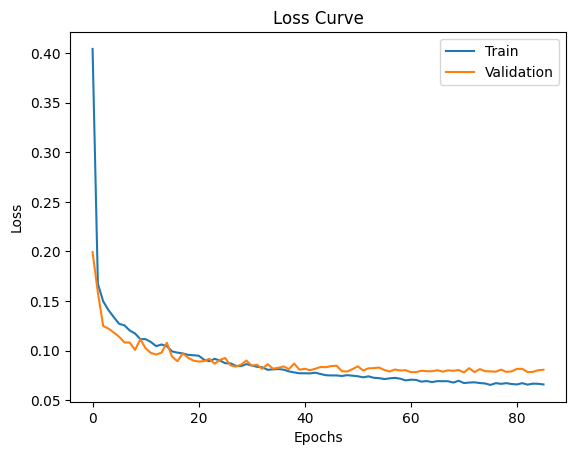

In [14]:
plot_loss(log_path=config["save_path"], savefig=True)

In [15]:
# Evaluate
preds_norm, y_true_norm = evaluate_model(model, test_loader, DEVICE, config, precomputed=True)

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\GNN\..\helper.py:283: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device

Loaded weights from best_model_gnn_icecube.pth
Average test MSE: 0.0717


In [16]:
# Denormalize for plotting
label_mean = np.array([xpos_mean, ypos_mean])
label_std  = np.array([xpos_std,  ypos_std])

preds  = preds_norm  * label_std + label_mean
y_true = y_true_norm * label_std + label_mean

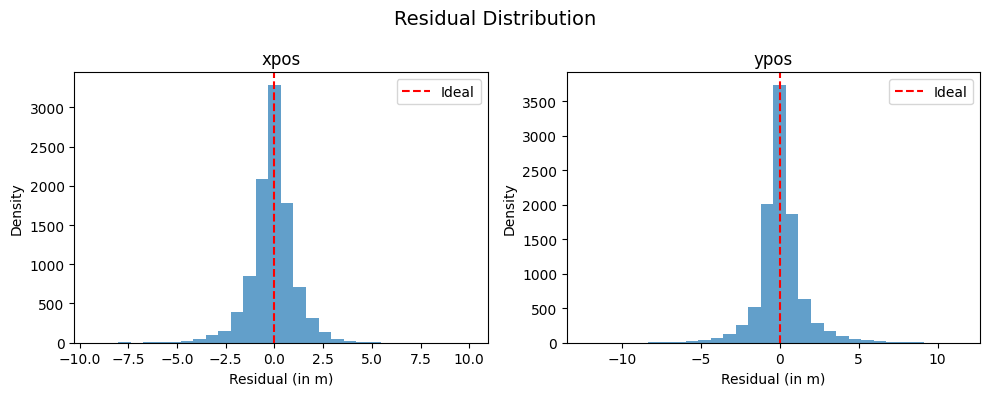


-- Test-set residual statistics --
  xpos: mean=-0.0841 m | std=1.1474 m | MAE=0.7921 m
  ypos: mean=0.0502 m | std=1.5082 m | MAE=0.9518 m


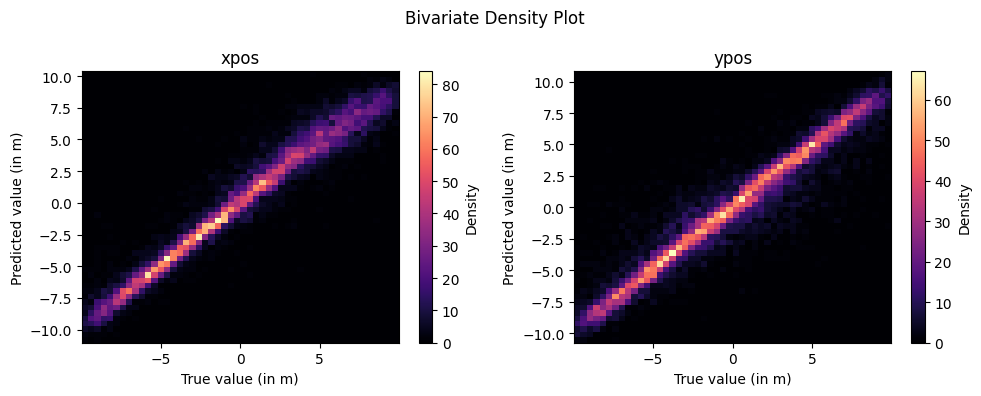

In [17]:
# Plots

label_names = ["xpos", "ypos"]
label_units = ["m", "m"]
plot_residuals(y_true, preds, label_names, label_units, savefig=True)


residuals = y_true - preds
print("\n-- Test-set residual statistics --")
for i, name in enumerate(label_names):
    print(f"  {name}: mean={residuals[:,i].mean():.4f} m | "
        f"std={residuals[:,i].std():.4f} m | "
        f"MAE={np.abs(residuals[:,i]).mean():.4f} m")
    
plot_heatmap(y_true, preds, label_names, label_units, savefig=True)

In [18]:
def plot_event(dataset, event_idx, pred_x=None, pred_y=None,
                label_mean=None, label_std=None):

    times = awkward.to_numpy(dataset["data"][event_idx, 0, :])
    hits_x = awkward.to_numpy(dataset["data"][event_idx, 1, :])
    hits_y = awkward.to_numpy(dataset["data"][event_idx, 2, :])

    # denormalize
    true_x = dataset["xpos"][event_idx] * label_std[0] + label_mean[0]
    true_y = dataset["ypos"][event_idx] * label_std[1] + label_mean[1]

    fig, ax = plt.subplots(figsize=(7, 6))

    sc = ax.scatter(hits_x, hits_y, c=times, cmap="magma", s=30)
    plt.colorbar(sc, ax=ax, label = "Hit time (in ns)")

    ax.scatter(true_x, true_y, c="green", s=150, marker="*",
                label="True")

    if pred_x is not None:
        err = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
        ax.scatter(pred_x, pred_y, c="blue", s=120, marker="X",
                label=f"Pred : Error = {err:.3f}m")

        ax.plot([true_x, pred_x], [true_y, pred_y], '--')


    ax.grid(alpha = 0.6)
    ax.legend()
    plt.title(f"Neutrino Event {event_idx}")
    plt.xlabel("x_pos (in m)")
    plt.ylabel("y_pos (in m)")
    plt.show()

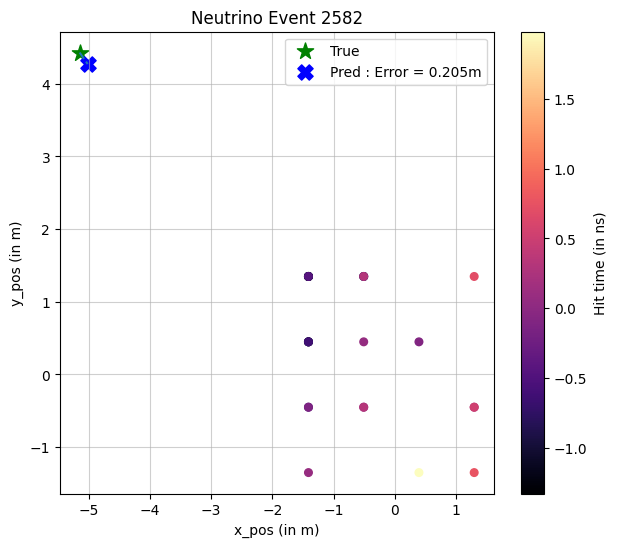

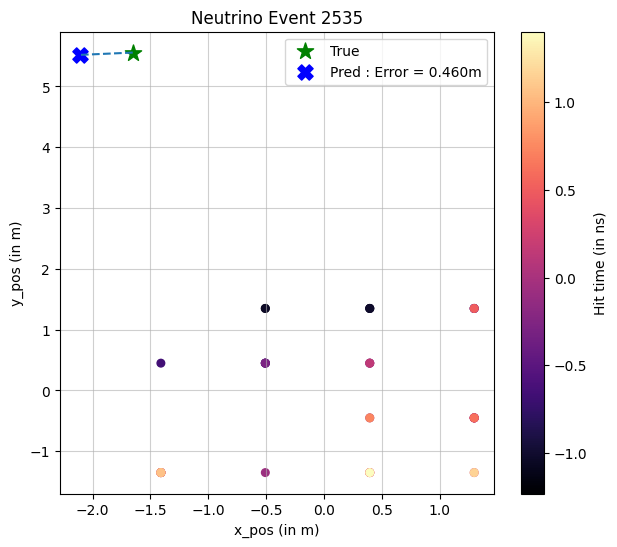

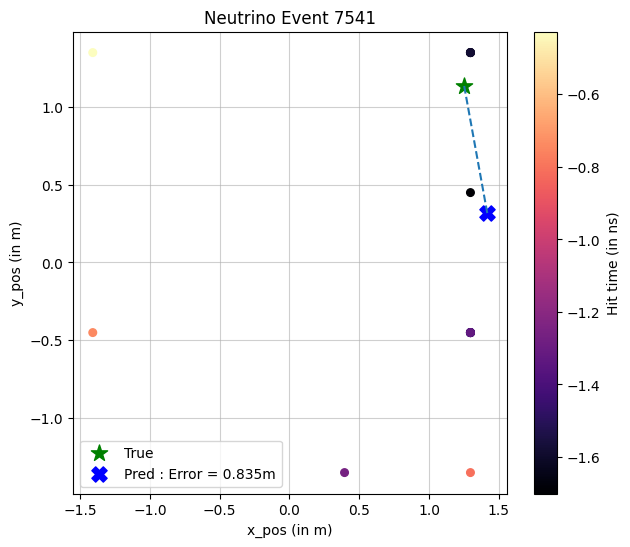

In [19]:
nums = np.random.choice(len(test_dataset), 3, replace=False)

for i in nums:
    plot_event(test_dataset, i, pred_x=preds[i, 0], pred_y=preds[i, 1], label_mean = label_mean, label_std = label_std)